# 04 - GloVe vs FastText
---

In the previous notebook, we learned **Word2Vec**.

Word2Vec represents words as dense vectors and captures semantic similarity.

However, Word2Vec still has limitations.

In this notebook, we will compare two important improvements:

1. **GloVe**
2. **FastText**

## 📜 History

After Word2Vec became popular, researchers explored better ways to learn word embeddings.

Two important methods appeared:

### GloVe

GloVe stands for **Global Vectors for Word Representation**.

It was developed by Stanford researchers.

GloVe uses global word co-occurrence statistics.

This means it studies how often words appear together across a large corpus.

### FastText

FastText was developed by Facebook AI Research.

Unlike Word2Vec, FastText does not learn only full words.

It breaks words into smaller pieces called **subwords**.

This helps FastText understand rare words and unseen words better.

## ❌ Why Word2Vec Was Not Enough

Word2Vec was powerful, but it had some limitations.

### 1. One word = one vector

The word **bank** gets one vector.

But:

- river bank
- bank account

have different meanings.

Word2Vec cannot fully solve this.

### 2. Weak with rare words

If a word appears very few times, Word2Vec may not learn a good vector.

### 3. Cannot handle unseen words

If a word was not present during training, Word2Vec cannot create a vector for it.

Example:

- ChatGPT
- DeepSeek
- misspelled words
- new technical terms

FastText was created to solve this using subwords.

## 💡 Core Idea

### Word2Vec

Learns word vectors using nearby context words.

### GloVe

Learns word vectors using global co-occurrence statistics.

### FastText

Learns word vectors using subwords.

Example:

word = playing

subwords:

- pla
- lay
- ayi
- yin
- ing

So even if the full word is rare, FastText can learn from its parts.

## 🧠 Word2Vec vs GloVe vs FastText

| Model | Main Idea | Strength |
|---|---|---|
| Word2Vec | Predict words from context | Captures semantic similarity |
| GloVe | Uses global co-occurrence matrix | Good global word statistics |
| FastText | Uses subwords | Handles rare and unseen words better |

In [1]:

#Cell 7 — Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec, FastText
from sklearn.decomposition import PCA

In [2]:
corpus = [
    ["i", "love", "machine", "learning"],
    ["machine", "learning", "is", "powerful"],
    ["deep", "learning", "uses", "neural", "networks"],
    ["artificial", "intelligence", "is", "the", "future"],
    ["python", "is", "great", "for", "ai"],
    ["natural", "language", "processing", "uses", "text"],
    ["transformers", "changed", "natural", "language", "processing"],
    ["fasttext", "uses", "subword", "information"],
    ["glove", "uses", "global", "word", "statistics"],
    ["word2vec", "learns", "word", "vectors"]
]

corpus

[['i', 'love', 'machine', 'learning'],
 ['machine', 'learning', 'is', 'powerful'],
 ['deep', 'learning', 'uses', 'neural', 'networks'],
 ['artificial', 'intelligence', 'is', 'the', 'future'],
 ['python', 'is', 'great', 'for', 'ai'],
 ['natural', 'language', 'processing', 'uses', 'text'],
 ['transformers', 'changed', 'natural', 'language', 'processing'],
 ['fasttext', 'uses', 'subword', 'information'],
 ['glove', 'uses', 'global', 'word', 'statistics'],
 ['word2vec', 'learns', 'word', 'vectors']]

In [3]:
# train Word2Vec model
word2vec_model = Word2Vec(
    sentences=corpus,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    seed=42
)

print("Word2Vec vocabulary:")
print(word2vec_model.wv.index_to_key)

Word2Vec vocabulary:
['uses', 'is', 'learning', 'word', 'processing', 'language', 'natural', 'machine', 'vectors', 'learns', 'word2vec', 'statistics', 'global', 'glove', 'information', 'subword', 'fasttext', 'changed', 'transformers', 'text', 'ai', 'for', 'great', 'python', 'future', 'the', 'intelligence', 'artificial', 'networks', 'neural', 'deep', 'powerful', 'love', 'i']


In [4]:
# Train FastText model
fasttext_model = FastText(
    sentences=corpus,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1,
    seed=42
)

print("FastText vocabulary:")
print(fasttext_model.wv.index_to_key)

FastText vocabulary:
['uses', 'is', 'learning', 'word', 'processing', 'language', 'natural', 'machine', 'vectors', 'learns', 'word2vec', 'statistics', 'global', 'glove', 'information', 'subword', 'fasttext', 'changed', 'transformers', 'text', 'ai', 'for', 'great', 'python', 'future', 'the', 'intelligence', 'artificial', 'networks', 'neural', 'deep', 'powerful', 'love', 'i']


# Compare word vector

In [5]:
word = "learning"

print("Word2Vec vector for:", word)
print(word2vec_model.wv[word][:10])

print()

print("FastText vector for:", word)
print(fasttext_model.wv[word][:10])

Word2Vec vector for: learning
[ 0.01330947 -0.01200367  0.01219596 -0.01970551  0.0118737   0.01147697
  0.01121457  0.00659403 -0.00113732  0.00820661]

FastText vector for: learning
[ 4.3891509e-05  2.5840802e-03  1.0711878e-03  9.5275365e-04
  1.4201121e-04  5.7119789e-04  4.9089844e-04 -3.0018035e-03
 -7.3523633e-04  9.1545173e-04]


In [6]:
# Simillar words

print("Word2Vec similar words:")
print(word2vec_model.wv.most_similar("learning", topn=5))

print()

print("FastText similar words:")
print(fasttext_model.wv.most_similar("learning", topn=5))

Word2Vec similar words:
[('ai', 0.22354106605052948), ('word', 0.22082702815532684), ('the', 0.19635871052742004), ('text', 0.1946219950914383), ('machine', 0.19057117402553558)]

FastText similar words:
[('learns', 0.4021475315093994), ('artificial', 0.2953265607357025), ('vectors', 0.23137877881526947), ('is', 0.22951075434684753), ('language', 0.1333366483449936)]


## ⚠️ Unseen Word Problem

Now we test a word that was not present in training.

Example:

```text
learnable

~Word2Vec usually fails because it only knows words from the vocabulary.

~FastText can still generate a vector because it uses subwords.

# Word2Vec on Unseen Word

In [7]:
 
unseen_word = "learnable"

try:
    print(word2vec_model.wv[unseen_word])
except KeyError as e:
    print("Word2Vec error:")
    print(e)

Word2Vec error:
"Key 'learnable' not present"


# FastText on Unseen Word

In [8]:
unseen_word = "learnable"

print("FastText can create vector for unseen word:")
print(fasttext_model.wv[unseen_word][:10])

FastText can create vector for unseen word:
[-0.00113827  0.00432107  0.0002449   0.00216366  0.00156467 -0.00172552
  0.00046818 -0.00056538 -0.00338859 -0.00100252]


## 🧠 Why FastText Works Better for Unseen Words

FastText breaks words into character n-grams.

Example:

```text
learning

can become:

lea
ear
arn
rni
nin
ing

So when it sees:

learnable

it recognizes parts like:

lea
ear
arn

This helps it create a useful vector even if the full word was never seen.

#  Visualize Embeddings

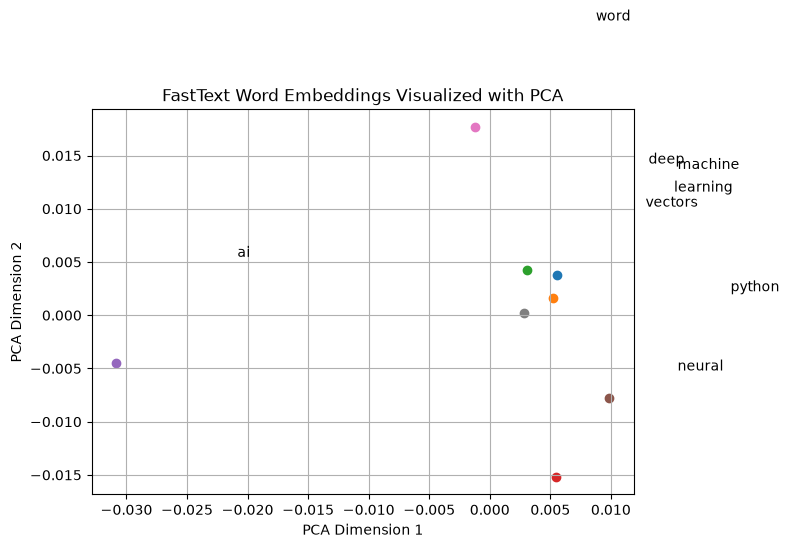

In [10]:

words = ["machine", "learning", "deep", "neural", "ai", "python", "word", "vectors"]

vectors = [fasttext_model.wv[word] for word in words]

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

plt.figure(figsize=(7, 5))

for word, vector in zip(words, reduced_vectors):
    plt.scatter(vector[0], vector[1])
    plt.text(vector[0] + 0.01, vector[1] + 0.01, word)

plt.title("FastText Word Embeddings Visualized with PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid()
plt.show()

## 🧠 GloVe Concept

GloVe is different from Word2Vec and FastText.

Word2Vec and FastText are prediction-based models.

GloVe is count-based.

It builds a large word co-occurrence matrix.

Example:

| Word | appears with AI | appears with learning | appears with python |
|---|---:|---:|---:|
| machine | 5 | 10 | 2 |
| deep | 2 | 8 | 1 |
| neural | 1 | 5 | 0 |

GloVe learns embeddings from this global co-occurrence information.

# Manual Co-occurrence Example

In [11]:
from collections import defaultdict

documents = [
    "machine learning is powerful",
    "deep learning uses neural networks",
    "python is great for machine learning"
]

window_size = 2
co_occurrence = defaultdict(int)

for doc in documents:
    tokens = doc.split()

    for i, word in enumerate(tokens):
        start = max(0, i - window_size)
        end = min(len(tokens), i + window_size + 1)

        for j in range(start, end):
            if i != j:
                pair = (word, tokens[j])
                co_occurrence[pair] += 1

co_occurrence_df = pd.DataFrame(
    [(w1, w2, count) for (w1, w2), count in co_occurrence.items()],
    columns=["Word", "Context Word", "Count"]
)

co_occurrence_df.head(20)

,Word,Context Word,Count
0,machine,learning,2
1,machine,is,1
2,learning,machine,2
3,learning,is,1
4,learning,powerful,1
5,is,machine,1
6,is,learning,1
7,is,powerful,1
8,powerful,learning,1
9,powerful,is,1


## ✅ Advantages

### GloVe

- Uses global word statistics
- Good for capturing broad semantic relationships
- Often works well with large corpora

### FastText

- Handles rare words better
- Can create vectors for unseen words
- Useful for misspellings and morphologically rich languages

## ❌ Disadvantages

### GloVe

- Needs large co-occurrence matrix
- Cannot naturally handle unseen words
- Still gives one vector per word

### FastText

- Better for unseen words, but still not truly contextual
- Same word still usually has one meaning vector
- Cannot fully understand sentence meaning

## 🚨 Remaining Problem

Even after Word2Vec, GloVe, and FastText, one major problem remains:

They represent words, but not full sentence meaning very well.

Example:

```text
Dog bites man
Man bites dog

Both sentences contain the same words.

But the meaning is very different.

To understand this, models need to process word order and sequence.

This leads us to RNNs.

## ✅ Summary

Today I learned:

- Word2Vec learns word embeddings from local context.
- GloVe learns embeddings from global co-occurrence statistics.
- FastText learns embeddings using subwords.
- FastText can handle unseen words better than Word2Vec.
- Static embeddings still cannot fully understand word order or sentence meaning.